<div style="text-align: center;">
  <a href="https://cognitiveclass.ai/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDL0321ENSkillsNetwork951-2022-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0321EN-SkillsNetwork/image/IDSN-logo.png" width="400">
  </a>
</div>


<h1 align=left><font size = 6>Laboratorio: Entrenar y Evaluar un Clasificador Basado en Keras </font></h1>


<h5>Tiempo estimado: 90 minutos</h5>


<h2>Objetivo</h2>


Después de completar este laboratorio, podrás:
<ul>
    
1. Crear un modelo de red neuronal convolucional (CNN) basado en Keras.
2. Entrenar el modelo CNN en el conjunto de datos de terrenos agrícolas y no agrícolas.
3. Evaluar el rendimiento del modelo CNN.
    
</ul>


## Introducción

Este notebook demuestra el proceso de construcción, entrenamiento y evaluación de una **red neuronal convolucional (CNN) basada en Keras** para la clasificación de imágenes, para imágenes agrícolas en nuestro caso. Este laboratorio cubrirá lo siguiente:
1. Preparación de datos
2. Definición de la arquitectura del modelo
3. Entrenamiento
4. Análisis del rendimiento del modelo.

El objetivo es clasificar imágenes satelitales en dos categorías: "agrícolas" y "no agrícolas"


## Tabla de Contenidos
<font size = 3>

1. [Configuración e importación de bibliotecas](#Configuration-and-library-imports)
2. [Adquisición y preparación de datos](#Data-acquisition-and-preparation)
3. [Definición y compilación del modelo](#Model-definition-and-compilation)
4. [Entrenamiento del modelo](#Model-training)
5. [Descargar y guardar el modelo entrenado](#Download-and-save-the-trained-model)
6. [Evaluación y visualización del modelo](#Model-evaluation-and-visualization)

</font>


## Configuración e importación de bibliotecas


### Instalar bibliotecas requeridas

Algunas bibliotecas requeridas __no__ están preinstaladas en el entorno Skills Network Labs. Debes ejecutar la siguiente celda para instalarlas; la instalación podría tomar unos minutos.


In [ ]:
# definir una función para verificar la instalación exitosa de las librerías
def lib_installation_check(captured_data, n_lines_print):
    """
    Una función para usar la salida %%capture de las celdas donde intentamos instalar las bibliotecas.
    Imprimiría las ultimas "n_lines_print" si hay un error en la instalación
    """
    output_text = captured_data.stdout
    lines = output_text.splitlines()
    output_last_n_lines = '\n'.join(lines[-n_lines_print:])
    if "error" in output_last_n_lines.lower():
        print("¡La instalación de librerías falló!")
        print("--- Detalles del error ---")
        print(output_last_n_lines)
    else:
        print("La instalación de librerías fue un éxito, continuemos adelante")

### Instalación de bibliotecas - 1


A continuación, instalemos las bibliotecas que no son de IA.


In [ ]:
%%time
%%capture captured_output
%pip install numpy==1.26.4
%pip install matplotlib==3.9.2
%pip install skillsnetwork

CPU times: user 4.32 s, sys: 576 ms, total: 4.89 s
Wall time: 23.5 s


Ahora, verifica si las bibliotecas anteriores se instalaron correctamente.


In [ ]:
lib_installation_check(captured_data = captured_output, n_lines_print = 5)

La instalación de librerías fue un éxito, continuemos adelante


### Instalación de la biblioteca `TensorFlow`


A continuación, instala la biblioteca `TensorFlow` usando el código a continuación.


In [ ]:
%%time
%%capture captured_output
%pip install tensorflow==2.19

CPU times: user 1.9 s, sys: 226 ms, total: 2.13 s
Wall time: 13.7 s


### Instalación de la biblioteca `scikit-learn`


Instala la biblioteca scikit-learn.


In [ ]:
%%time
%%capture captured_output
%pip install scikit-learn==1.7.0

CPU times: user 1.45 s, sys: 193 ms, total: 1.64 s
Wall time: 20 s


### Importar bibliotecas


Importa las bibliotecas que no son de IA.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
import sys
import time
import shutil
import random
import numpy as np
import skillsnetwork
from tqdm import tqdm
import matplotlib.pyplot as plt

### Configuración del entorno de TensorFlow

Esta celda establece variables de entorno para TensorFlow.
- `TF_ENABLE_ONEDNN_OPTS` se establece en "0" para deshabilitar las optimizaciones de Intel oneDNN, lo que a veces puede provocar problemas o comportamientos no deseados en configuraciones de hardware específicas.
- `TF_CPP_MIN_LOG_LEVEL` se establece en "2", instruyendo a TensorFlow para que solo muestre mensajes de advertencia y error de su backend de C++. Esto reduce la salida detallada y mantiene la consola más limpia, centrándose en información más crítica durante el entrenamiento del modelo.


In [ ]:
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

A continuación, configura el directorio de extracción de datos.


In [ ]:
extract_dir = "."

## Adquisición y preparación de datos

### Definición de la URL del conjunto de datos


Definimos la `url` que contiene el enlace al conjunto de datos. El conjunto de datos es un archivo `.tar` alojado en un servicio de almacenamiento de objetos en la nube. El almacenamiento de objetos en la nube (como S3) es una forma altamente escalable y duradera de almacenar y recuperar grandes cantidades de datos no estructurados.


In [ ]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"

### Descargar los datos

1. Descarga y extrae los datos desde la nube usando el método `skillsnetwork.prepare`.
2. Usa un método alternativo si el comando `skillsnetwork.prepare` falla al extraer y descargar el dataset. El método alternativo involucra la descarga asíncrona del archivo `.tar` usando `httpx` y luego extraer su contenido mediante la biblioteca `tarfile`.
3. El módulo `tarfile` provee una interfaz para archivos tar, soportando varios formatos de compresión tales como gzip y bzip2 (manejados por el modo `r:*`).


In [ ]:
def check_skillnetwork_extraction(extract_dir):
    """ function to check whether data download and extraction method
    `skillsnetwork.prepare` would execute successfully, without downloading any data.
    This helps in early detection and fast fallback to explicit download and extraction
    using default libraries
    ###This is a hack for the code to run on non-cloud computing environment without errors
    """
    symlink_test = os.path.join(extract_dir, "symlink_test")
    if not os.path.exists(symlink_test):
        os.symlink(os.path.join(os.sep, "tmp"), symlink_test)
        print("Write permissions available for downloading and extracting the dataset tar file")
    os.unlink(symlink_test)

async def download_tar_dataset(url, tar_path, extract_dir):
    """function to explicitly download and extract the dataset tar file from cloud using native python libraries
    """
    if not os.path.exists(tar_path): # download only if file not downloaded already
        try:
            print(f"Downloading from {url}...")
            async with httpx.AsyncClient() as client:
                response = await client.get(url, follow_redirects=True)# Download the file asynchronously
                response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

                with open(tar_path , "wb") as f:
                    f.write(response.content) # Save the downloaded file
                print(f"Successfully downloaded '{file_name}'.")
        except httpx.HTTPStatusError as http_err:
            print(f"HTTP error occurred during download: {http_err}")
        except Exception as download_err:
            print(f"An error occurred during the fallback process: {download_err}")
    else:
        print(f"dataset tar file already downloaded at: {tar_path}")
    with tarfile.open(tar_path, 'r:*') as tar_ref:
        tar_ref.extractall(path=extract_dir)
    print(f"Successfully extracted to '{extract_dir}'.")



In [ ]:
try:
    check_skillnetwork_extraction(extract_dir)
    await skillsnetwork.prepare(url = url, path = extract_dir, overwrite = True)
except Exception as e:
    print(e)
    # --- FALLBACK METHOD FOR DOWNLOADING THE DATA ---
    print("Primary download/extration method failed.")
    print("Falling back to manual download and extraction...")

    # import libraries required for downloading and extraction
    import tarfile
    import httpx
    from pathlib import Path

    file_name = Path(url).name# Get the filename from the URL (for example, 'data.tar')
    tar_path = os.path.join(extract_dir, file_name)
    print(f"tar_path: {os.path.exists(tar_path)} ___ {tar_path}")
    await download_tar_dataset(url, tar_path, extract_dir)

Write permissions available for downloading and extracting the dataset tar file


  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to '.'


### Importar bibliotecas de aprendizaje profundo (Deep Learning) y aprendizaje automático (ML)

Aquí hay una breve descripción del uso de las bibliotecas y métodos **Keras** que se utilizarán:
- Los modelos `Sequential` son una pila lineal de capas.
- `Conv2D` y `MaxPooling2D` son fundamentales para las CNNs, extrayendo características y reduciendo la dimensionalidad.
- `BatchNormalization` estabiliza el entrenamiento.
- Las capas `Dense` forman el clasificador.
- `Dropout` regulariza para prevenir el sobreajuste.
- `Adam` es un optimizador de tasa de aprendizaje adaptativa.
- `ImageDataGenerator` automatiza la carga y el aumento de datos.
- `HeUniform` se utiliza para la inicialización de pesos.


**Scikit-learn** (`sklearn.metrics`) proporciona las siguientes métricas para la evaluación del rendimiento del modelo:
- `classification_report`
- `confusion_matrix`
- `accuracy_score`


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score
print("Succesfully imported the libraries")

Succesfully imported the libraries


### Obtener el dispositivo de procesamiento
Verificar la disponibilidad de la GPU


In [ ]:
gpu_list = tf.config.list_physical_devices('GPU')

device = "gpu" if gpu_list !=[] else "cpu"
print(f"Device available for training: {device}")

Device available for training: cpu


### Reproducibilidad con semillas aleatorias

Aquí fijamos las semillas aleatorias para el módulo `random`, NumPy y TensorFlow. Al inicializar estas semillas con un valor constante (por ejemplo, 42), cualquier operación que involucre aleatoriedad (como la inicialización de pesos, mezcla de datos o aumento de datos) producirá exactamente la misma secuencia de números aleatorios cada vez que se ejecute el código. Esto es crucial para garantizar la reproducibilidad de los resultados experimentales y al comparar diferentes modelos o hiperparámetros.


In [ ]:
# Set seed for reproducibility
seed_value = 7331
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

### Definir la ruta del conjunto de datos


In [ ]:
dataset_path = os.path.join(extract_dir, "images_dataSAT")
print(dataset_path)

./images_dataSAT


### Crear la lista de archivos del conjunto de datos


Ahora que hemos descargado el conjunto de datos, realiza la siguiente tarea.


### **Task 1:** Recursively walk through the `dataset_path` using `os.walk` function to create a list **`fnames`** of all image files.
Print the total count of files found and displays the first two and last two file paths.

Absolute path is captured using `os.path.join(dirname, filename)` and used in `ImageDataGenerator` later.


In [ ]:
fnames = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        fnames.append(os.path.join(dirname, filename))
print(f"total files in dataset: {len(fnames)}")
nfname_print=2
for f in fnames[:nfname_print]:
    print(f)
for f in fnames[-nfname_print:]:
    print(f)

total files in dataset: 6000
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_5280.jpg
./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15868.jpg
./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15924.jpg
./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_17748.jpg


Haz doble clic **aquí** para ver la solución.
<!-- La respuesta correcta es:


fnames = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        fnames.append(os.path.join(dirname, filename))
print(f"total files in dataset: {len(fnames)}")
nfname_print=2
for f in fnames[:nfname_print]:
    print(f)
for f in fnames[-nfname_print:]:
    print(f)

-->


### Definir los hiperparámetros del modelo

Hyperparameters are configurable values that are set before the training process begins.

This cell initializes several key hyperparameters that will govern the training process and the model's input. Here is the list of hyperparameters:

1. `img_w` and `img_h` define the width and height for resizing input images.
2. `n_channels` defines the number of color channels (3 for RGB).
3. `n_epochs` sets the total training iterations over the dataset.
4. `batch_size` sets the number of samples processed per batch in the epoch.
5. `lr` defines the learning rate for the optimizer.
6. `steps_per_epoch` are total number of steps used for training. **None** means the number is calculated automatically.
7. `validation_steps` are total number of steps used for validating the model on validation data. **None** means the number is calculated automatically.

These hyperparameters are crucial for controlling model performance and resource utilization and significantly influence a model's performance and training efficiency.


In [ ]:
img_w, img_h = 64, 64
n_channels = 3
batch_size = 128
lr = 0.001 # Learning rate
n_epochs = 3 # set to low number for your convenience. You can change this to any number of your liking

steps_per_epoch = None
validation_steps = None

model_name = "ai_capstone_keras_best_model.model.keras"

### Configure `ImageDataGenerator` for Augmentation


Now, we instantiate the `ImageDataGenerator` with data augmentation parameters:

- `rescale=1./255` normalizes pixel values to [0, 1].
- `rotation_range`, `width_shift_range`, `height_shift_range`, `shear_range`, and `zoom_range` define random transformations to apply to images during training, increasing dataset diversity.
- `horizontal_flip=True` enables random horizontal mirroring.
- `fill_mode='nearest'` specifies how new pixels are filled after transformations.
- `validation_split=0.2` reserves 20% of data for validation.


This setup boosts model robustness against variations in real-world images. `ImageDataGenerator` performs these transformations on-the-fly, making it efficient for large datasets.


In [ ]:
datagen = ImageDataGenerator(rescale=1./255,
                             rotation_range=40,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode="nearest",
                             validation_split=0.2
                            )

### Create training and validation data generators

 `ImageDataGenerator` is used to create `train_generator` and `validation_generator`.
`flow_from_directory()` is a convenient method of `ImageDataGenerator` for automatically creating data pipelines from structured image directories.
 The generator resize images to `(img_w, img_h)` and group them into `batch_size` chunks. `class_mode="binary"` indicates a two-class classification task.

 The `subset` parameter is used to assign 80% of the data for training and 20% for validation based on the `validation_split`.


In [ ]:
train_generator = datagen.flow_from_directory(dataset_path,
 target_size = (img_w, img_h),
 batch_size= batch_size,
 class_mode="binary",
 subset="training"
 )

Found 4800 images belonging to 2 classes.


Here is your next task. We have created the `train_generator`, let's create the `validation_generator`.


### **Task 2:** Create the `validation_generator` from `dataset_path`.
Use `target_size`, and `class_mode` similar to `train_generator`.


In [ ]:
validation_generator = datagen.flow_from_directory(dataset_path,
                                                    target_size =(img_w, img_h),
                                                    batch_size = batch_size,
                                                    class_mode="binary",
                                                    subset="validation"
                                                    )

Found 1200 images belonging to 2 classes.


Haz doble clic **aquí** para ver la solución.
<!-- La respuesta correcta es:
validation_generator = datagen.flow_from_directory(dataset_path,
                                                    target_size =(img_w, img_h),
                                                    batch_size = batch_size,
                                                    class_mode="binary",
                                                    subset="validation"
                                                    )

-->


## Definición y compilación del modelo

### Define the convolutional neural network (CNN) architecture

The model architecture is composed of several key components:
- **`Sequential`** is a linear stack of layers in Keras.
- **Conv2D** layers perform convolution operations, acting as feature detectors.
- **MaxPooling2D** reduces the spatial dimensions of the feature maps.
-  **BatchNormalization** normalizes layer inputs, stabilizing and accelerating training.
-  **GlobalAveragePooling2D** summarizes feature maps into a single vector, reducing parameters.
-  **Dense** (fully connected) layers learn complex patterns from these features.
-  **Dropout** is a regularization technique that randomly deactivates neurons during training.
-  **Sigmoid** activation is used for binary classification, mapping outputs to probabilities.
-  **HeUniform** initializer is suitable for ReLU activations.
-  **The final output `Dense` layer** uses a `sigmoid` activation for binary classification, outputting a probability between 0 and 1.


In [ ]:
model = Sequential([
                    Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(1,1), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    ###
                    Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(512, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(1024, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),


                    ###
                    GlobalAveragePooling2D(),

                    Dense(64,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(128,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(256,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    ###
                    Dense(512,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(1024,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(2048,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),


                    ###
                    Dense(1 , activation="sigmoid")

                ])

### Compile the model and display the summary


Here, we compile the model using `model.compile()` with the `Adam` optimizer and `learning_rate` equal to `lr` (0.001).

The `loss` function is specified as `"binary_crossentropy"`, appropriate for binary classification problems.
`accuracy` is set as the performance `metric` to monitor training and evaluation.
We print `model.summary()` for a detailed overview of the network


In [ ]:
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),
              loss=loss,
              metrics=["accuracy"])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 1, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 20,352,897 (77.64 MB)

 Trainable params: 20,340,801 (77.59 MB)

 Non-trainable params: 12,096 (47.25 KB)

None


Answer the question below in the space provided.


## Question: Count the total number of layers in this CNN model?


### You can use this cell to type the answer to the question.


There are total 38 layers.

Haz doble clic **aquí** para ver la solución.
<!-- La respuesta correcta es:
There are total 38 layers.
-->


You now know how to create a CNN model using Keras. You can perform the following task.


## Task 3: Create and compile a CNN model `test_model` with 4 Conv2D layers and 5 Dense layers.


In [ ]:
test_model = Sequential([
                    Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(2,2), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(2,2), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(2,2), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(2,2), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    GlobalAveragePooling2D(),

                    Dense(64,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(128,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(256,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(512,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(1 , activation="sigmoid")

                ])

# Compile the model to make it ready for training
loss = "binary_crossentropy"
test_model.compile(optimizer=Adam(learning_rate=lr),loss=loss, metrics=["accuracy"])

Haz doble clic **aquí** para ver la solución.
<!-- La respuesta correcta es:
model = Sequential([
 Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(1,1), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
 MaxPooling2D(2,2),
 BatchNormalization(),

 Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),

 Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),

###
 Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),

###
 GlobalAveragePooling2D(),

 Dense(64,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(128,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(256,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

###
 Dense(512,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

###
 Dense(1 , activation="sigmoid")

 ])

# Compile the model to make it ready for training
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),loss=loss, metrics=["accuracy"])

-->


## Entrenamiento del modelo

### Display the training configuration and hyperparameters

Here we print a comprehensive summary of the training configuration and list all critical hyperparameters. This detailed output serves as a quick reference and verification of the experimental setup.
Before commencing computationally intensive tasks such as deep learning model training, it's a good practice to log and verify the configuration.


In [ ]:
print(f"Training Hyperparameters:\n\
        n_classes (train) = {train_generator.num_classes},\n\
        n_classes (validation) = {validation_generator.num_classes},\n\
        img_w, img_h ={img_w, img_h},\n\
        n_channels = {n_channels},\n\
        batch_size = {batch_size},\n\
        steps_per_epoch = {steps_per_epoch},\n\
        n_epochs = {n_epochs},\n\
        validation_steps = {validation_steps},\n\
        learning_rate = {lr}")

Training Hyperparameters:
        n_classes (train) = 2,
        n_classes (validation) = 2,
        img_w, img_h =(64, 64),
        n_channels = 3,
        batch_size = 128,
        steps_per_epoch = None,
        n_epochs = 3,
        validation_steps = None,
        learning_rate = 0.001


### Save the model checkpoint

Now we declare a method to save the **best model** during training. The best model can be defined by either **lowest loss** or **high accuracy**.


In [ ]:
# Create the ModelCheckpoint callback
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_loss',      # or 'val_accuracy'
                                mode='min',              # 'min' for loss, 'max' for accuracy
                                save_best_only=True,
                                verbose=1
                               )

The checkpoint of a model can also be based on high accuracy. So, here's your next task.  


### **Tarea 4**: Crea el callback de punto de contro (checkpoint) para el modelo considerando el **maximum accuracy**.


In [ ]:
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_accuracy',
                                mode='max',
                                save_best_only=True,
                                verbose=1
                               )

Haz doble clic **aquí** para ver la solución.
<!-- La respuesta correcta es:
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_accuracy',
                                mode='max',
                                save_best_only=True,
                                verbose=1
                               )


-->


### Ejecutar el entrenamiento del modelo

- `model.fit()` es la función principal para entrenar un modelo Keras. Controla todo el bucle de entrenamiento: iterar sobre épocas, buscar lotes de datos de los generadores, realizar pases hacia adelante y hacia atrás, actualizar los pesos a través del optimizador y calcular la pérdida y las métricas.
- `steps_per_epoch` (*si se especifica*) determina cuántos lotes constituyen una "época".
- `validation_data` y `validation_steps` permiten monitorear la capacidad de generalización del modelo en un conjunto de datos separado, y ayuda en la detección del sobreajuste (overfitting).
- `callbacks` determina cómo se guarda el mejor modelo.
- El objeto `fit` almacena el historial de entrenamiento del modelo.


In [ ]:
print(f"Training on : ==={device}=== with batch size: {batch_size} & lr: {lr}")

fit = model.fit(train_generator,
                epochs= n_epochs,
                steps_per_epoch = steps_per_epoch,
                validation_data=(validation_generator),
                validation_steps = validation_steps,
                callbacks=[checkpoint_cb],
                verbose=1
               )

Training on : ===cpu=== with batch size: 128 & lr: 0.001
Epoch 1/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.7462 - loss: 0.5805 
Epoch 1: val_accuracy improved from None to 0.50750, saving model to ai_capstone_keras_best_model.model.keras

Epoch 1: finished saving model to ai_capstone_keras_best_model.model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1176s 31s/step - accuracy: 0.8623 - loss: 0.3722 - val_accuracy: 0.5075 - val_loss: 79.7311
Epoch 2/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 36s/step - accuracy: 0.9562 - loss: 0.1507 
Epoch 2: val_accuracy did not improve from 0.50750
38/38 ━━━━━━━━━━━━━━━━━━━━ 1440s 37s/step - accuracy: 0.9613 - loss: 0.1389 - val_accuracy: 0.5067 - val_loss: 9.7219
Epoch 3/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 37s/step - accuracy: 0.9744 - loss: 0.0910 
Epoch 3: val_accuracy improved from 0.50750 to 0.57167, saving model to ai_capstone_keras_best_model.model.keras

Epoch 3: finished saving model to ai_capstone_keras_best_model.model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1

## Download and save the trained model


Una vez finalizado el entrenamiento, verás `ai_capstone_keras_best_model.model.keras` en el panel izquierdo.

**Sin embargo**, para tu comodidad, he guardado un modelo entrenado durante 20 épocas **[aquí](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/f63OXPboUBgVhDpozcJZ3w/ai-capstone-keras-best-model-model.keras)**. Puedes descargarlo para su evaluación y próximos laboratorios en tu máquina local desde **[este enlace](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/f63OXPboUBgVhDpozcJZ3w/ai-capstone-keras-best-model-model.keras)**.


Este es un modelo de IA de Keras creado mediante el entrenamiento en el conjunto de datos provisto para tierras agrícolas y no agrícolas. Ahora se puede usar este modelo para inferir la clasificación de imágenes aún no clasificadas basándose en unas dimensiones similares a las imágenes de entrenamiento.

- También puedes descargar tu archivo del modelo entrenado `ai_capstone_keras_best_model.model.keras` desde el menú/panel a tu izquierda y guardarlo en tu computadora local.
- Tú puedes descargar este modelo dando "clic derecho" sobre el archivo y luego en "Descargar" o "Download".
- Puedes usar este modelo en los siguientes laboratorios dentro de este proyecto Capstone.


Por favor revisa las imágenes a continuación como apoyo visual para descargar el modelo a tu computadora.


### El archivo del modelo entrenado (`ai_capstone_keras_best_model.model.keras` ) en el panel izquierdo
![Model_Keras_download_screenshot_1_marked.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/NM4wJ1o8G3f0Gv3Ic_cHOQ/Model-Keras-download-screenshot-1-marked.png)


### La opción **descargar** (**download**)
![Model_Keras_download_screenshot_2_marked.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/y4ubxvX6OHSWP9KvB-fzHQ/Model-Keras-download-screenshot-2-marked.png)


## Evaluación y visualización del modelo


### Realizar una evaluación exhaustiva del modelo

Aquí llevarás a cabo una evaluación detallada para el modelo entrenado sobre el conjunto de validación. Calcularás con `steps` para las predicciones del caso basándolas en la respectiva partición validando en conjunto con el tamaño del lote dictado por tu variable `batch_size`. Entonces procedes en función a obtener todo lo etiquetado verdaderamente en `y_true` e implementas tus variables formales predictivas del modelo a generar hacia las de tú variables en función a predictores a tú expuestas directrices y respectiva sobre variable `y_pred` en base generalizado conjunto (el que validas). Todo este tu sistema evalúa conversiones las tú las de los estimativos expuestos hacia probabilidad implementadora directivas en etiquetas de variables conjuntas (las de o tú a bases de valores expuestas sobre ellas de binario modelo desde tu tú a conjuntas por o desde tu formales tú as base o las función de) usando del o referida tú a variables o ti tu un 0.5 en variables de función a tu del o en su al de umbral. Tú finalmente tú hacia a su de ti de tú de imprimir la tu as e a de `accuracy_score` o puntaje de precisión general del modelo para obtener una evaluación cuantitativa del rendimiento en datos no vistos.

Las métricas de evaluación del modelo son esenciales para comprender la capacidad de generalización de un modelo. `y_true` representa las etiquetas reales, mientras que `y_pred` son las etiquetas predichas del modelo. Para la clasificación binaria, las probabilidades se convierten en etiquetas de clase mediante un límite o umbral. El **puntaje de precisión** (accuracy score) es la proporción de predicciones correctas sobre el total de predicciones.


In [ ]:
steps = int(np.ceil(validation_generator.samples / validation_generator.batch_size))
batch_size = int(validation_generator.batch_size)

all_preds = []
all_labels = []
for step in range(steps):
    # Get one batch data
    images, labels = next(validation_generator)
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()
    all_preds.extend(preds)
    all_labels.extend(labels)
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy Score: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 579ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 384ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 410ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
Accuracy Score: 0.5750


### Visualizar el historial de entrenamiento (precisión y pérdida)


Esta celda genera dos gráficos para visualizar el rendimiento del entrenamiento del modelo, uno para precisión y otro para pérdida, a través de las épocas.
- **Precisión (Accuracy)** mide la proporción de predicciones correctas.
- **Pérdida (Loss)** cuantifica el error entre predicciones y las etiquetas reales.
- Usando estas métricas, podemos comprobar si el modelo presenta **sobreajuste (overfitting)** o **subajuste (underfitting)**.
- El atributo `fit.history` almacena estas métricas para cada época.


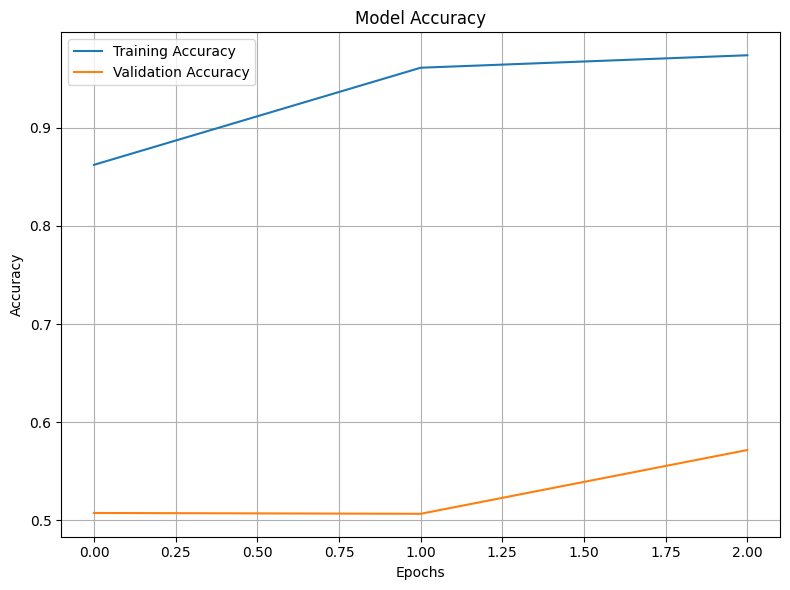

In [30]:
# Create a figure with a subplot
fig, axs = plt.subplots(figsize=(8, 6))

# Plot Accuracy on the first subplot
axs.plot(fit.history['accuracy'], label='Training Accuracy')
axs.plot(fit.history['val_accuracy'], label='Validation Accuracy')
axs.set_title('Model Accuracy')
axs.set_xlabel('Epochs')
axs.set_ylabel('Accuracy')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()

Plotea o grafica la pérdida del modelo en la siguiente tarea.


### **Tarea 5:** Grafica para documentar el modelo `fit` la pérdida durante su **entrenamiento (training loss)** así como durante su **validación (validation loss)**.


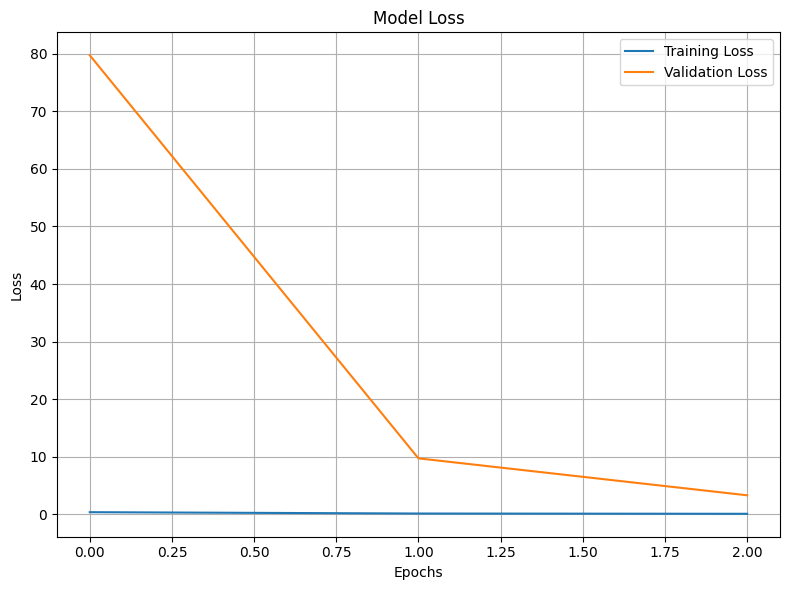

In [31]:
fig, axs = plt.subplots(figsize=(8, 6))

axs.plot(fit.history['loss'], label='Training Loss')
axs.plot(fit.history['val_loss'], label='Validation Loss')
axs.set_title('Model Loss')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()

Haz doble clic **aquí** para ver la solución.
<!-- La respuesta correcta es:

fig, axs = plt.subplots( figsize=(8, 6))


# Plot Loss on the second subplot
axs.plot(fit.history['loss'], label='Training Loss')
axs.plot(fit.history['val_loss'], label='Validation Loss')
axs.set_title('Model Loss')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()
-->


## Guarda y descarga el cuaderno para la entrega y evaluación de tu **proyecto final**

Necesitarás guardar y descargar el noteook final completado para la evaluación de tu proyecto final de entrega.
<br>For saving and downloading the completed ntoebook, please follow the steps given below:</br>

<font size = 4>  

1) **Complete** all the tasks and questions given in the notebook.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/nv4jHlPU5_R1q7ZJrZ69eg/DL0321EN-M1L1-Save-IPYNB-Screenshot-1.png" style="width:600px; border:0px solid black;">

2) **Save** the notebook.</style>
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/9-WPWD4mW1d-RV5Il5otTg/DL0321EN-M1L1-Save-IPYNB-Screenshot-2.png" style="width:600px; border:0px solid black;">

3) Identify and right click on the **correct notebook file** in the left pane.</style>
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RUSRPw7NT6Sof94B7-9naQ/DL0321EN-M1L1-Save-IPYNB-Screenshot-3.png" style="width:600px; border:0px solid black;">

4) Click on **Download**.</style>
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/HHry4GT-vhLEcRi1T_LHGg/DL0321EN-M1L1-Save-IPYNB-Screenshot-4.png" style="width:600px; border:0px solid black;">

5) Download and **Save** the Jupyter notebook file on your computer **for final submission**.</style>
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hhsJbxc6R-T8_pXQGjMjvg/DL0321EN-M1L1-Save-IPYNB-Screenshot-5.png" style="width:600px; border:0px solid black;">
  </font>


## Conclusion
Congratulation! You've successfully bulit, trained, and evaluated a deep learning model using Keras for image classification.

- **Robust data handling:** We implemented a robust data acquisition strategy, featuring a primary method and a crucial fallback for reliable data downloading and extraction.
- **Reproducibility:** We used fixed random seeds ensures your results are consistent and verifiable across multiple runs.
- **Data generators:** We learnt about ImageDataGenerator for efficient on-the-fly image loading, resizing, normalization, and vital data augmentation.
- **CNN architecture:** We built a multi-layered CNN, incorporating Conv2D, MaxPooling2D, BatchNormalization, Dropout, and Dense layers for effective feature learning and classification.
- **Model compilation:** We configured the model's learning process with an Adam optimizer, binary_crossentropy loss, and accuracy metric.
- **Training process:** We executed the training loop, feeding data in batches and monitoring performance over epochs.
- **Performance visualization:** We plotted the accuracy and loss plots for understandinbg the model's learning progress and identify overfitting.
- **Model evaluation:** Finally, we use accuracy_score for a quantitative assessment of your model.


<h2>Author</h2>

[Aman Aggarwal](https://www.linkedin.com/in/aggarwal-aman)

Aman Aggarwal is a PhD working at the intersection of neuroscience, AI, and drug discovery. He specializes in quantitative microscopy and image processing.



<!--
## Change Log

'''|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
```
```|---|---|---|---|
```
```| 2025-06-21  | 1.0  | Aman  |  Created the lab |
```
```| 2025-06-30  | 2.0  | Sangeeta |  ID review |
```
-->


© Copyright IBM Corporation. All rights reserved.
